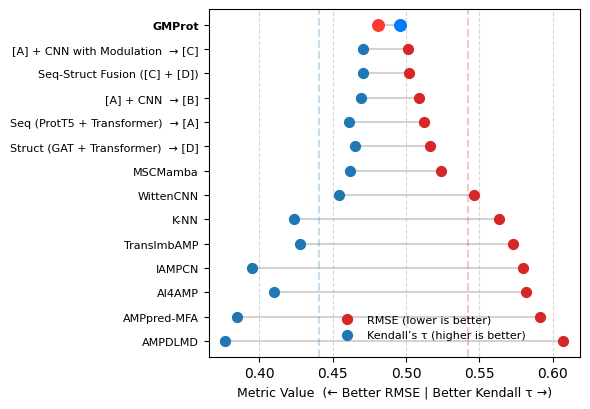

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Models and metrics
models = [
    "MSCMamba",
    "GMProt",
    "Seq (ProtT5 + Transformer)  → [A]",
    "[A] + CNN  → [B]",
    "[A] + CNN with Modulation  → [C]",

    "Struct (GAT + Transformer)  → [D]",
    "Seq-Struct Fusion ([C] + [D])",

    "IAMPCN",
    "WittenCNN",
    "AI4AMP",
    "AMPDLMD",
    "K-NN",
    "AMPpred-MFA",
    "TranslmbAMP",
]

rmse = np.array([0.524, 0.481, 0.512, 0.509, 0.501, 
                 0.516, 0.502,
                 0.580, 0.546, 0.582, 0.607, 0.563, 0.591, 0.573])
kendall = np.array([0.462, 0.496, 0.461, 0.469, 0.471,
                    0.465, 0.471,
                     0.395, 0.454, 0.410, 0.377, 0.424, 0.385, 0.428])

# Sort by RMSE
order = np.argsort(rmse)
models = [models[i] for i in order]
rmse = rmse[order]
kendall = kendall[order]

y = np.arange(len(models))
mopro_index = models.index("GMProt")

# Figure
fig, ax = plt.subplots(figsize=(6, 4.2))  # Slightly smaller for single-column

# Connector lines
for i in range(len(models)):
    ax.plot([rmse[i], kendall[i]], [y[i], y[i]], color='lightgray', lw=1.5, zorder=1)

# Scatter points
ax.scatter(rmse, y, color='#d62728', s=50, label='RMSE (lower is better)', zorder=2)
ax.scatter(kendall, y, color='#1f77b4', s=50, label="Kendall’s τ (higher is better)", zorder=2)

# Highlight MoPro
ax.scatter(rmse[mopro_index], y[mopro_index], color='#ff3b30', s=70, zorder=3)
ax.scatter(kendall[mopro_index], y[mopro_index], color='#007aff', s=70, zorder=3)

# Reference lines (mean)
ax.axvline(np.mean(rmse), color='#d62728', linestyle='--', alpha=0.25)
ax.axvline(np.mean(kendall), color='#1f77b4', linestyle='--', alpha=0.25)

# Y-axis
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=8)
ax.invert_yaxis()  # Best model on top

# X-axis label
ax.set_xlabel('Metric Value  (← Better RMSE | Better Kendall τ →)', fontsize=9)

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Legend
ax.legend(frameon=False, loc='lower right', bbox_to_anchor=(0.88, 0.02), fontsize=8)

labels = ax.get_yticklabels()
for label in labels:
    if label.get_text() == "GMProt":
        label.set_fontweight("bold")

# Tight layout
plt.tight_layout()
plt.savefig('../result/performance_plot.png', dpi=600, bbox_inches='tight')
plt.show()
